## Comparative Performance Evaluation of Decision Tree, KNN, Naive Bayes, and Artificial Neural Network for Marketing Campaign Response Prediction
Apil Maraseni
ACE079BCT012


In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

## Load the Dataset



In [58]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

## Display Basic Information


In [59]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Explore Dataset Structure


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Statistical Summary



In [61]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


## Check Missing Values


In [62]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

## Check Duplicate Records


In [63]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Analyze the Target Variable


Response
0    1906
1     334
Name: count, dtype: int64


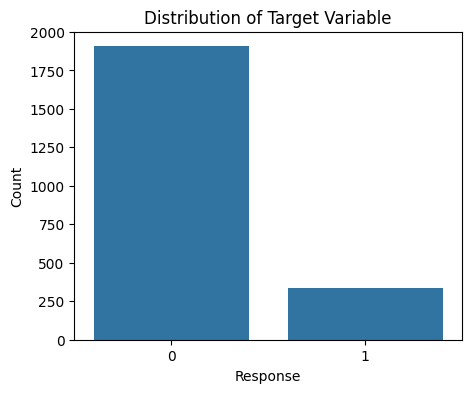

In [64]:
print(df["Response"].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x="Response", data=df)
plt.title("Distribution of Target Variable")
plt.xlabel("Response")
plt.ylabel("Count")
plt.show()

## Visualize Missing Values


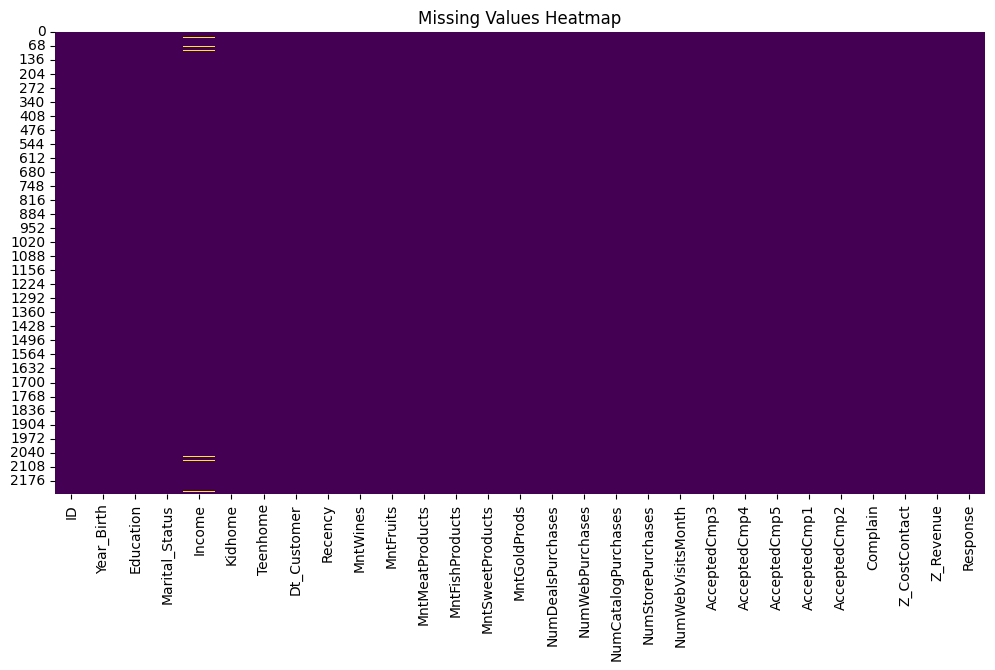

In [65]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

## Explore Numerical Features


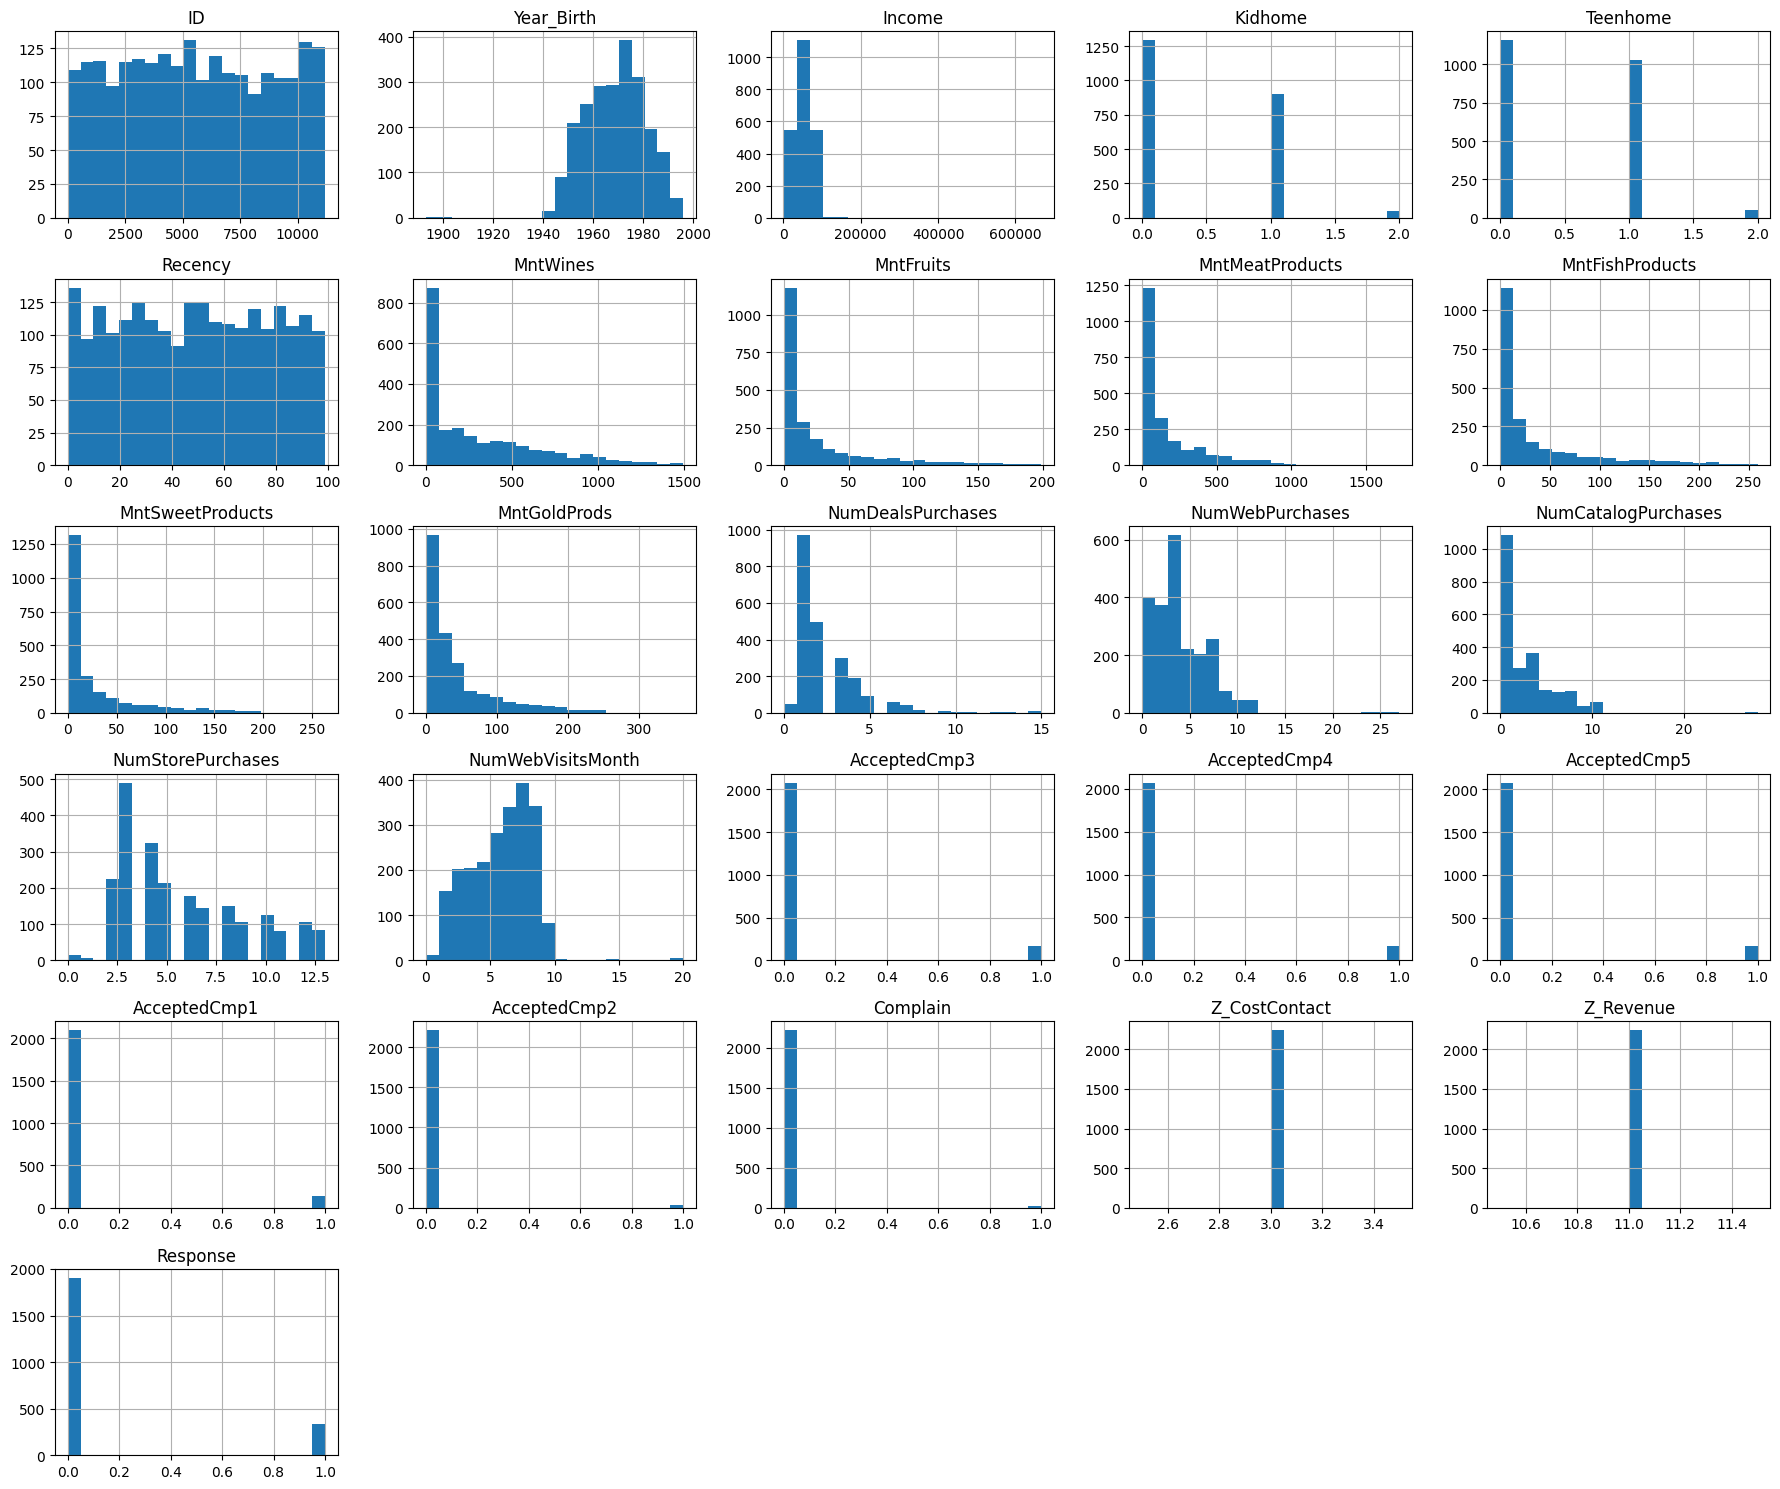

In [66]:
df.hist(figsize=(18,15), bins=20)
plt.tight_layout()
plt.show()

## Correlation Analysis


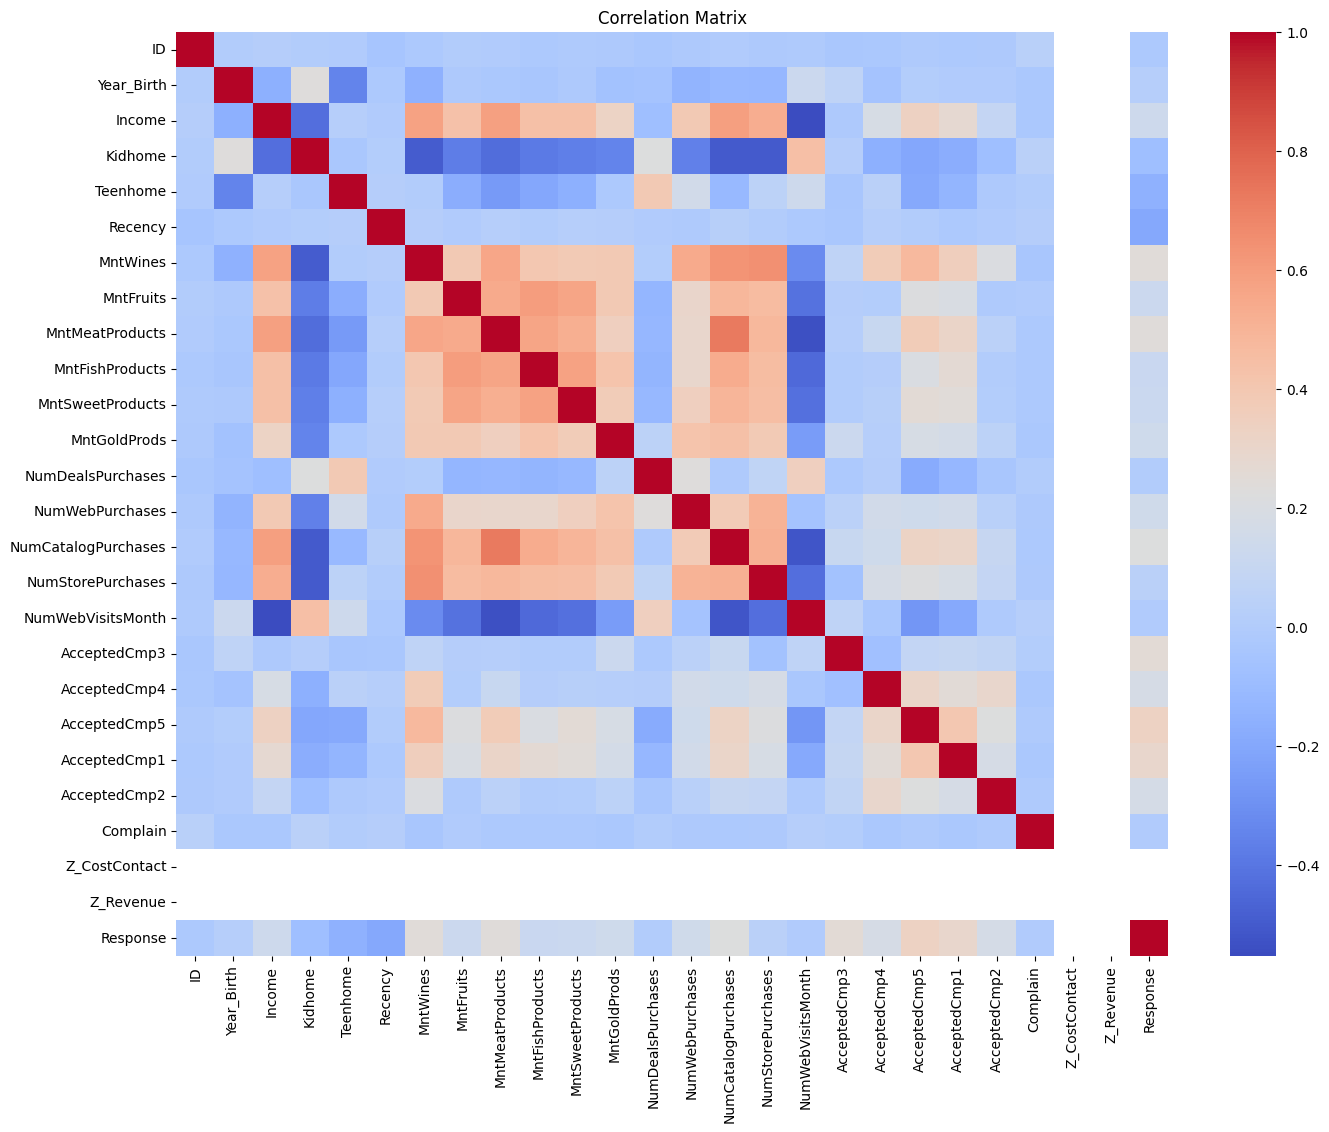

In [67]:
plt.figure(figsize=(16,12))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("Correlation Matrix")
plt.show()

## Explore Categorical Features

In [68]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Education
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Dt_Customer
Dt_Customer
31-08-2012    12
12-05-2014    11
14-02-2013    11
12-09-2012    11
22-05-2014    10
              ..
01-11-2013     1
10-08-2013     1
11-10-2012     1
20-12-2012     1
09-01-2014     1
Name: count, Length: 663, dtype: int64


## Handle Missing Values


In [69]:
df["Income"].fillna(df["Income"].median(), inplace=True)

print(df.isnull().sum().sum())

0


## Remove Irrelevant Features


In [70]:
df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"], inplace=True)

df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,10,4,7,0,0,0,0,0,0,1
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,1,2,5,0,0,0,0,0,0,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,2,10,4,0,0,0,0,0,0,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,0,4,6,0,0,0,0,0,0,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,3,6,5,0,0,0,0,0,0,0


## Feature Engineering


In [71]:
# Convert date column to datetime
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

# Create Age
df["Age"] = 2026 - df["Year_Birth"]

# Create Customer Tenure (in days)
df["Customer_Tenure"] = (
    df["Dt_Customer"].max() - df["Dt_Customer"]
).dt.days

# Remove original columns
df.drop(columns=["Year_Birth", "Dt_Customer"], inplace=True)

df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Tenure
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,7,0,0,0,0,0,0,1,69,663
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,5,0,0,0,0,0,0,0,72,113
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,4,0,0,0,0,0,0,0,61,312
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,6,0,0,0,0,0,0,0,42,139
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,5,0,0,0,0,0,0,0,45,161


## Verify the Updated Dataset


In [72]:
print(df.shape)

df.head()

(2240, 26)


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Tenure
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,7,0,0,0,0,0,0,1,69,663
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,5,0,0,0,0,0,0,0,72,113
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,4,0,0,0,0,0,0,0,61,312
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,6,0,0,0,0,0,0,0,42,139
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,5,0,0,0,0,0,0,0,45,161


## Encode Categorical Variables


In [73]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ["Education", "Marital_Status"]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Tenure
0,2,4,58138.0,0,0,58,635,88,546,172,...,7,0,0,0,0,0,0,1,69,663
1,2,4,46344.0,1,1,38,11,1,6,2,...,5,0,0,0,0,0,0,0,72,113
2,2,5,71613.0,0,0,26,426,49,127,111,...,4,0,0,0,0,0,0,0,61,312
3,2,5,26646.0,1,0,26,11,4,20,10,...,6,0,0,0,0,0,0,0,42,139
4,4,3,58293.0,1,0,94,173,43,118,46,...,5,0,0,0,0,0,0,0,45,161


## Create Total Spending Feature


In [74]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df[["Total_Spending"]].head()

,Total_Spending
0,1617
1,27
2,776
3,53
4,422


## Separate Features and Target Variable


In [75]:
X = df.drop("Response", axis=1)
y = df["Response"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (2240, 26)
Target: (2240,)


## Split the Dataset


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1792, 26)
Testing Set: (448, 26)


## Feature Scaling


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Decision Tree Classifier


In [78]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

## Model Prediction


In [79]:
y_pred_dt = dt_model.predict(X_test)

## Model Evaluation


In [80]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Accuracy :", round(dt_accuracy,4))
print("Precision:", round(dt_precision,4))
print("Recall   :", round(dt_recall,4))
print("F1 Score :", round(dt_f1,4))

Accuracy : 0.8594
Precision: 0.5588
Recall   : 0.2836
F1 Score : 0.3762


## Classification Report


In [81]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       381
           1       0.56      0.28      0.38        67

    accuracy                           0.86       448
   macro avg       0.72      0.62      0.65       448
weighted avg       0.84      0.86      0.84       448



## Confusion Matrix


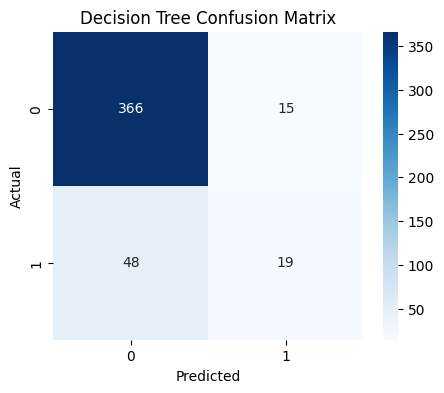

In [82]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

## Cross Validation


In [83]:
cv_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Accuracy:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross Validation Accuracy: [0.87053571 0.88392857 0.87276786 0.85491071 0.875     ]
Mean Accuracy: 0.8714285714285716


## Decision Tree Visualization


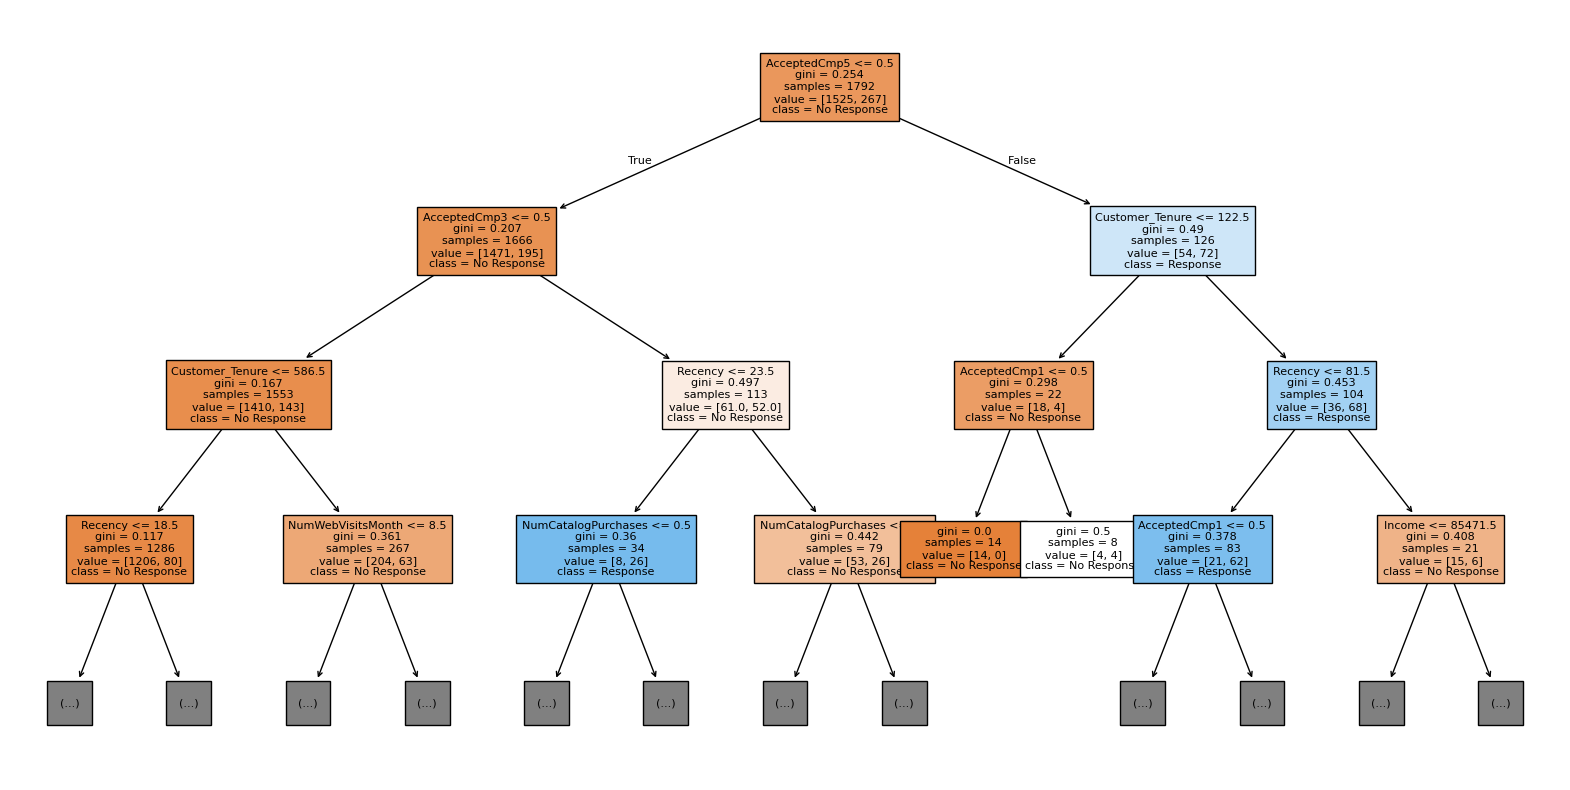

In [84]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    filled=True,
    fontsize=8,
    max_depth=3,
    feature_names=X.columns,
    class_names=["No Response", "Response"]
)

plt.show()

### Observation

After pruning the Decision Tree by limiting its depth and specifying minimum samples for splits and leaf nodes, the model achieved higher overall accuracy while reducing its complexity. Although the recall for the positive class decreased, the improvement in precision indicates that the model became more reliable when predicting customers who would respond to the marketing campaign.

## K-Nearest Neighbor (KNN) 


In [85]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Prediction

In [86]:
y_pred_knn = knn_model.predict(X_test_scaled)

## Model Evaluation

In [87]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1 Score :", round(knn_f1, 4))

Accuracy : 0.8638
Precision: 0.5882
Recall   : 0.2985
F1 Score : 0.396


## Classification Report

In [88]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92       381
           1       0.59      0.30      0.40        67

    accuracy                           0.86       448
   macro avg       0.74      0.63      0.66       448
weighted avg       0.84      0.86      0.84       448



## Confusion Matrix

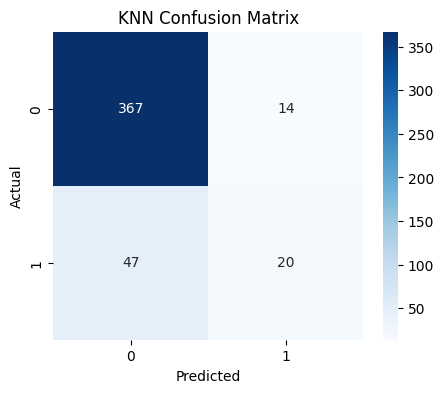

In [89]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [90]:
cv_scores_knn = cross_val_score(
    knn_model,
    scaler.fit_transform(X),
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Accuracy:", cv_scores_knn)
print("Mean Accuracy:", cv_scores_knn.mean())

Cross Validation Accuracy: [0.85714286 0.88392857 0.86383929 0.88169643 0.86383929]
Mean Accuracy: 0.8700892857142856



### Observation

KNN achieved slightly better precision and F1-score than the Decision Tree while maintaining the same overall accuracy.

## Naive Bayes Classifier

In [91]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [92]:
y_pred_nb = nb_model.predict(X_test_scaled)

In [93]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))

Accuracy : 0.7924
Precision: 0.3617
Recall   : 0.5075
F1 Score : 0.4224


In [94]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.91      0.84      0.87       381
           1       0.36      0.51      0.42        67

    accuracy                           0.79       448
   macro avg       0.63      0.67      0.65       448
weighted avg       0.83      0.79      0.81       448



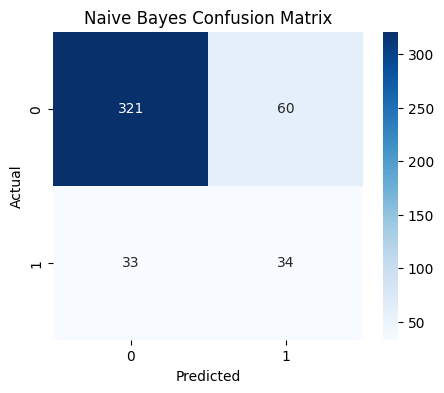

In [95]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [96]:
cv_scores_nb = cross_val_score(
    nb_model,
    scaler.fit_transform(X),
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Accuracy:", cv_scores_nb)
print("Mean Accuracy:", cv_scores_nb.mean())

Cross Validation Accuracy: [0.80803571 0.80803571 0.79910714 0.81919643 0.828125  ]
Mean Accuracy: 0.8125


### Observation

Naive Bayes achieved the highest recall but the lowest overall accuracy, indicating better detection of positive responses at the expense of more false predictions.

## Artificial Neural Network (ANN)

In [97]:
from sklearn.neural_network import MLPClassifier

ann_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

ann_model.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [98]:
y_pred_ann = ann_model.predict(X_test_scaled)

In [99]:
ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)

print("Accuracy :", round(ann_accuracy, 4))
print("Precision:", round(ann_precision, 4))
print("Recall   :", round(ann_recall, 4))
print("F1 Score :", round(ann_f1, 4))

Accuracy : 0.875
Precision: 0.6122
Recall   : 0.4478
F1 Score : 0.5172


In [100]:
print(classification_report(y_test, y_pred_ann))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       381
           1       0.61      0.45      0.52        67

    accuracy                           0.88       448
   macro avg       0.76      0.70      0.72       448
weighted avg       0.86      0.88      0.87       448



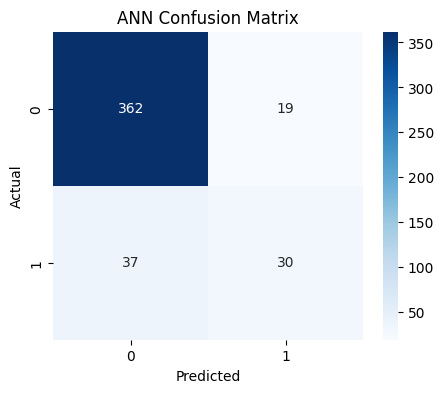

In [101]:
cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [102]:
cv_scores_ann = cross_val_score(
    ann_model,
    scaler.fit_transform(X),
    y,
    cv=3,
    scoring="accuracy"
)

print("Cross Validation Accuracy:", cv_scores_ann)
print("Mean Accuracy:", cv_scores_ann.mean())

Cross Validation Accuracy: [0.87014726 0.86345382 0.87265416]
Mean Accuracy: 0.8687517421488158


## Comparative Analysis

In [103]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "Naive Bayes",
        "ANN"
    ],
    "Accuracy": [
        dt_accuracy,
        knn_accuracy,
        nb_accuracy,
        ann_accuracy
    ],
    "Precision": [
        dt_precision,
        knn_precision,
        nb_precision,
        ann_precision
    ],
    "Recall": [
        dt_recall,
        knn_recall,
        nb_recall,
        ann_recall
    ],
    "F1-Score": [
        dt_f1,
        knn_f1,
        nb_f1,
        ann_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.859375,0.558824,0.283582,0.376238
1,KNN,0.863839,0.588235,0.298507,0.396040
2,Naive Bayes,0.792411,0.361702,0.507463,0.422360
3,ANN,0.875000,0.612245,0.447761,0.517241


## Best Model

In [104]:
best_model = results.loc[results["Accuracy"].idxmax()]

print(best_model)

Model             ANN
Accuracy        0.875
Precision    0.612245
Recall       0.447761
F1-Score     0.517241
Name: 3, dtype: object


## Observation


Among the four classifiers, the Artificial Neural Network (ANN) achieved the highest overall performance with an accuracy of 88% and the highest F1-score, making it the most effective model for predicting customer responses in this dataset.

## Conclusion

Four classification algorithms were implemented and compared using the Marketing Campaign dataset. Based on the evaluation metrics, the Artificial Neural Network outperformed the other models and provided the best overall classification performance.